In [1]:
import sys
sys.path.append(".") 

from utils import load_prices, compute_returns, build_network
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("Utils loaded successfully")

Utils loaded successfully


In [3]:
prices_full = load_prices(start="2019-01-01", end="2024-12-31")
returns_full = compute_returns(prices_full)
G_full, corr_full = build_network(returns_full, threshold=0.5)

#calm period - pre COVID
prices_calm = load_prices(start="2019-01-01", end="2020-01-01")
returns_calm = compute_returns(prices_calm)
G_calm, corr_calm = build_network(returns_calm, threshold=0.5)

#Crisis period - COVID crash
prices_covid = load_prices(start="2020-01-01", end="2020-06-30")
returns_covid = compute_returns(prices_covid)
G_covid, corr_covid = build_network(returns_covid, threshold=0.5)

#Crypto winter
prices_crypto = load_prices(start="2022-01-01", end="2022-12-31")
returns_crypto = compute_returns(prices_crypto)
G_crypto, corr_crypto = build_network(returns_crypto, threshold=0.5)

print(f"Full period:    {G_full.number_of_edges()} edges")
print(f"Calm period:    {G_calm.number_of_edges()} edges")
print(f"COVID crash:    {G_covid.number_of_edges()} edges")
print(f"Crypto winter:  {G_crypto.number_of_edges()} edges")

[*********************100%***********************]  55 of 55 completed
[**********************56%**                     ]  31 of 55 completed$SOL-USD: possibly delisted; no price data found  (1d 2019-01-01 -> 2020-01-01) (Yahoo error = "Data doesn't exist for startDate = 1546300800, endDate = 1577836800")
[*********************100%***********************]  55 of 55 completed

1 Failed download:
['SOL-USD']: possibly delisted; no price data found  (1d 2019-01-01 -> 2020-01-01) (Yahoo error = "Data doesn't exist for startDate = 1546300800, endDate = 1577836800")
[*********************100%***********************]  55 of 55 completed
[*********************100%***********************]  55 of 55 completed

Full period:    242 edges
Calm period:    148 edges
COVID crash:    1087 edges
Crypto winter:  540 edges


## Crisis period analysis — key finding

Edge counts by market regime:
- Calm (2019):        148 edges
- Full period:        242 edges  
- Crypto winter 2022: 540 edges
- COVID crash 2020:  1087 edges

During the COVID crash, the number of strongly correlated asset pairs increased 7x compared to the calm baseline. This confirms the correlation contagion hypothesis — diversification breaks down precisely during crisis periods when it is needed most. This has direct implications for portfolio construction: static correlation-based diversification is insufficient. Risk models must 
account for regime changes in network structure.

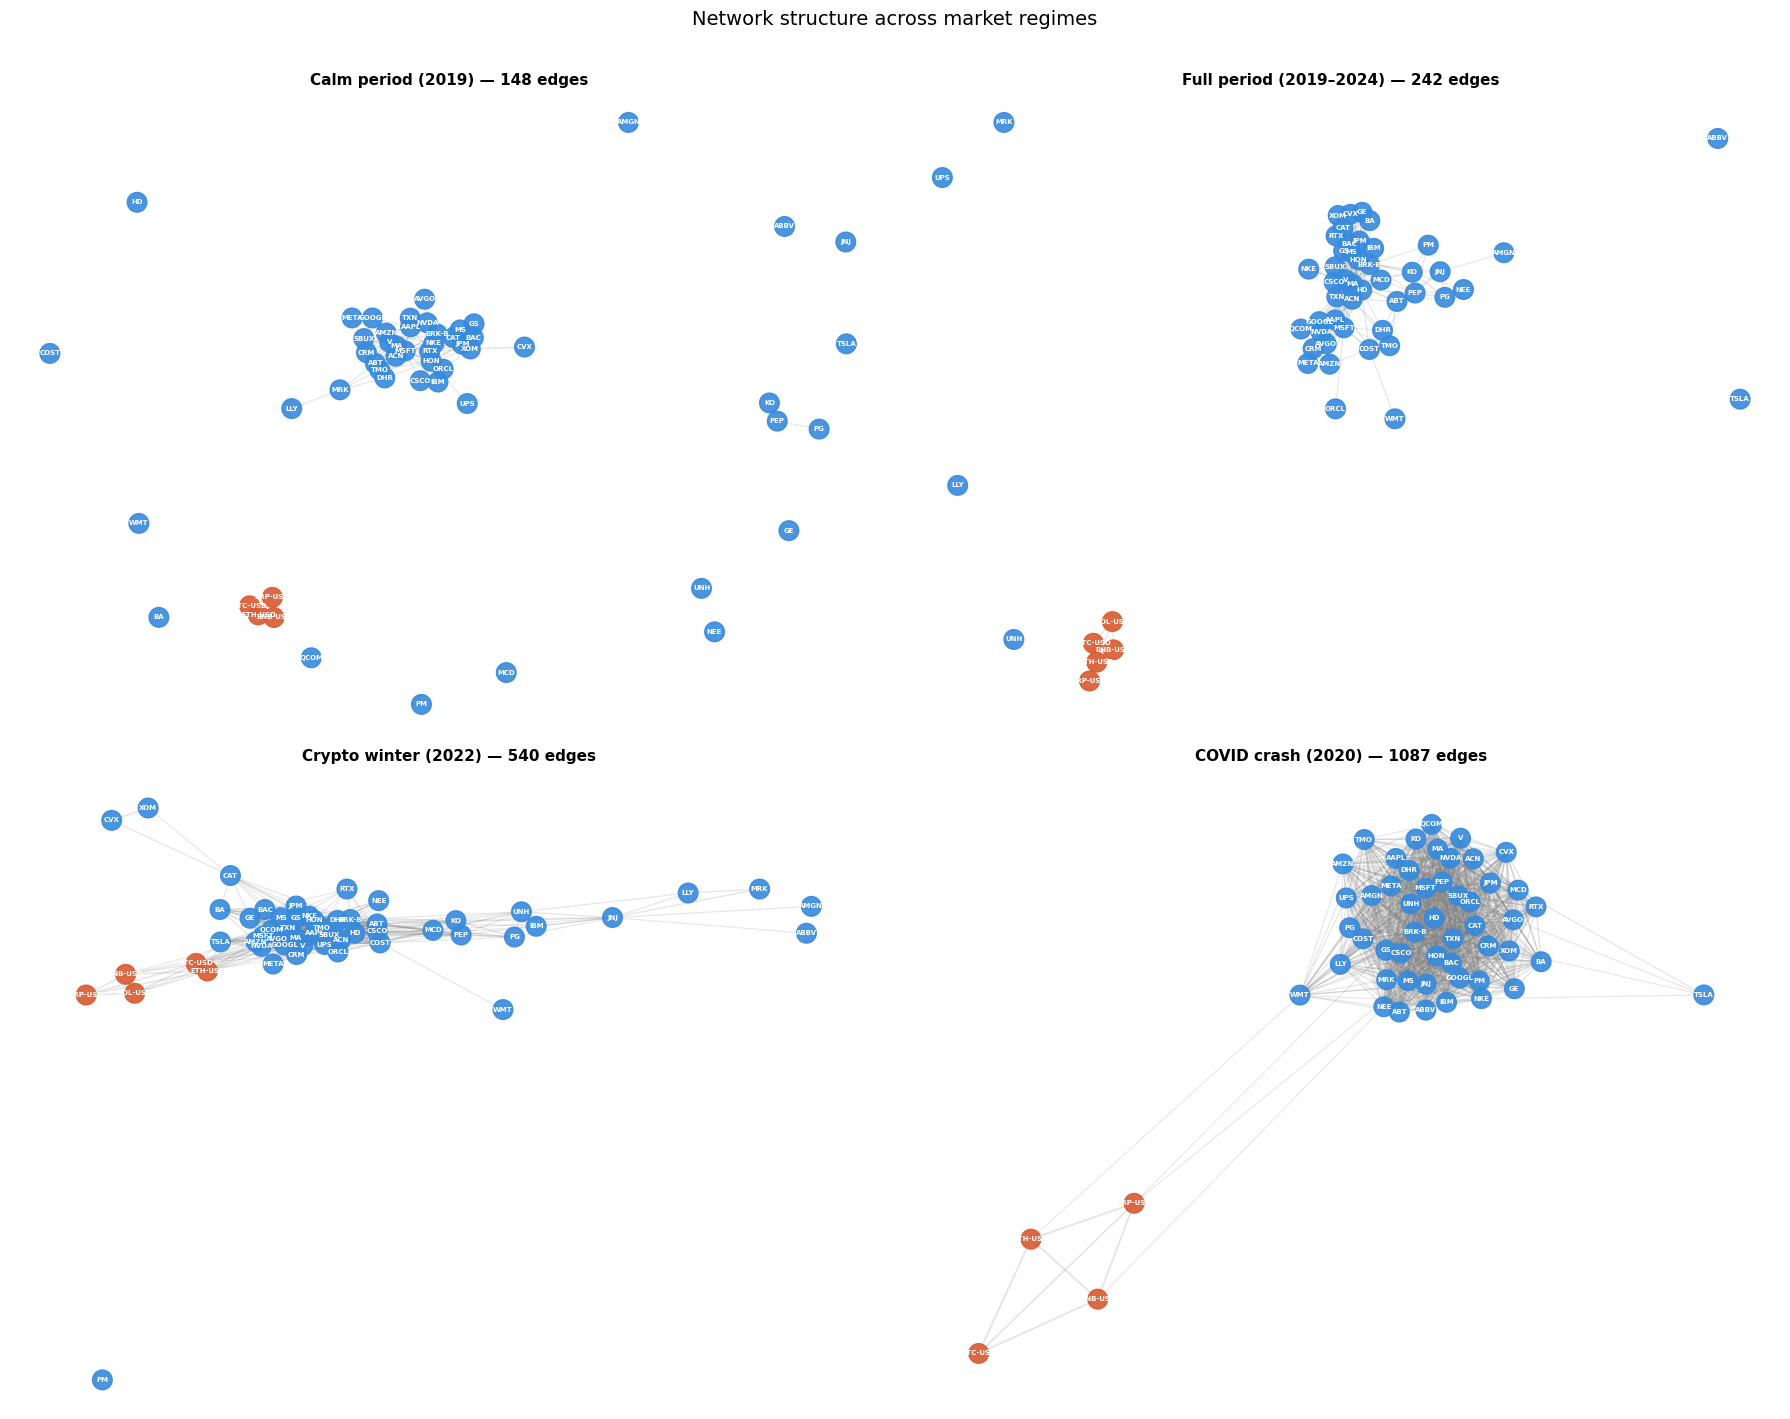

In [4]:
crypto = ["BTC-USD", "ETH-USD", "BNB-USD", "SOL-USD", "XRP-USD"]

periods = [
    (G_calm,   "Calm period (2019) — 148 edges"),
    (G_full,   "Full period (2019–2024) — 242 edges"),
    (G_crypto, "Crypto winter (2022) — 540 edges"),
    (G_covid,  "COVID crash (2020) — 1087 edges"),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for ax, (G, title) in zip(axes, periods):
    node_colors = ["#D85A30" if node in crypto else "#378ADD" for node in G.nodes()]
    edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
    edge_widths = [w * 1.5 for w in edge_weights]
    pos = nx.spring_layout(G, weight="weight", seed=42)

    nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                           node_size=200, alpha=0.9, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=5,
                            font_color="white", font_weight="bold", ax=ax)
    nx.draw_networkx_edges(G, pos, width=edge_widths,
                           alpha=0.2, edge_color="gray", ax=ax)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.axis("off")

plt.suptitle("Network structure across market regimes", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("crisis_network_comparison.png", dpi=150)
plt.show()

We can clearly notice in this figure how the network is changing across periods :
-   During calm period (2019), we have a loose sparse network. The main cluster exists, but clear gaps. Assets were doing their own thing.
-   Over the full period(2019-2024), we have a slightly denser network, but still many peripheral nodes. This is the average behaviour across 6 years masking the crisis period.
-   Crypto winter (2022), we can notice that the crypto cluster which were once separated has moved so close to the equity cluster that it created edges with it. This corresponds to the period when the cryptos crashed alongside with sensitive tech stocks in 2022.
-   Covid crash (2020), the entire equity market collapsed into one dense blob. Almost every stock was connected to almost every other stock. The network went from sparse to nearly fully connected. And the crypto separated completed to form their own cluster.

In [5]:
import networkx as nx

def network_stats(G, label):
    n = G.number_of_nodes()
    e = G.number_of_edges()
    possible = n * (n - 1) / 2
    density = e / possible
    degrees = [d for _, d in G.degree()]
    avg_degree = np.mean(degrees)
    return {
        "Period": label,
        "Edges": e,
        "Density": round(density, 4),
        "Avg degree": round(avg_degree, 2)
    }

stats = pd.DataFrame([
    network_stats(G_calm,   "Calm 2019"),
    network_stats(G_full,   "Full 2019-2024"),
    network_stats(G_crypto, "Crypto winter 2022"),
    network_stats(G_covid,  "COVID crash 2020"),
])

print(stats.to_string(index=False))

            Period  Edges  Density  Avg degree
         Calm 2019    148   0.1034        5.48
    Full 2019-2024    242   0.1630        8.80
Crypto winter 2022    540   0.3636       19.64
  COVID crash 2020   1087   0.7596       40.26


## Network density across market regimes

| Period             | Edges | Density | Avg degree |
|--------------------|-------|---------|------------|
| Calm 2019          | 148   | 0.10    | 5.5        |
| Full 2019-2024     | 242   | 0.16    | 8.8        |
| Crypto winter 2022 | 540   | 0.36    | 19.6       |
| COVID crash 2020   | 1087  | 0.76    | 40.3       |

Density is the fraction of all possible edges that actually exist — 0 means no connections, 1 means fully connected. Average degree is the average number of connections per node. 

Network density increased 7.3x from calm to COVID crash.
Average degree increased 7.4x — from 5.5 to 40.3 connections per asset.

Interpretation: during crisis periods, the market behaves as a single correlated system rather than a collection of diversifiable assets.
A portfolio optimized under calm-period correlations would have severely underestimated risk during the COVID crash.